In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
from torch.optim import Adam
import numpy as np
from tqdm import tqdm
import cv2
import os
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [2]:
images_path = "/kaggle/input/punch-dataset/punch_imgs"

In [3]:
try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
except:
    !pip install -q albumentations
    import albumentations as A
    from albumentations.pytorch import ToTensorV2

## Load Data

In [4]:
train_transform = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),
    A.Blur(blur_limit=3, p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

labels = {"miss": 0, "land": 1}
data = []
miss_count = 0
land_count = 0

for i in os.listdir(images_path):
    if i.lower().endswith(('.jpg', '.png', '.jpeg')):
        if "miss" in i.lower():
            label = labels["miss"]
            miss_count += 1
        elif "land" in i.lower():
            label = labels["land"]
            land_count += 1
        else:
            continue
        
        img_path = os.path.join(images_path, i)
        image = cv2.imread(img_path)
        
        if image is None:
            continue
        
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        data.append((image, label))

print(f"Total: {len(data)} | Miss: {miss_count} | Land: {land_count}")


/tmp/ipykernel_24/2186256296.py:5: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Total: 189 | Miss: 72 | Land: 117


## Dataset Class

In [5]:

class PunchDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        image, label = self.data[idx]
        
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        
        image = torch.from_numpy(image).permute(2, 0, 1).float()
        label = torch.tensor(label).long()
        
        return image, label

## Train/Test Split

In [6]:

train_len = int(0.8 * len(data))
test_len = len(data) - train_len

torch.manual_seed(42)
np.random.seed(42)

train_data, test_data = random_split(data, [train_len, test_len])

train_data_list = [data[i] for i in train_data.indices]
test_data_list = [data[i] for i in test_data.indices]

train_dataset = PunchDataset(train_data_list, transform=train_transform)
test_dataset = PunchDataset(test_data_list, transform=test_transform)

batch_size = 16 if device == "cuda" else 8

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, 
                         num_workers=2, pin_memory=True if device == "cuda" else False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, 
                        num_workers=2, pin_memory=True if device == "cuda" else False)

print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)} | Batch: {batch_size}")

Train: 151 | Test: 38 | Batch: 16


## Channel Attention

In [7]:

class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        b, c, _, _ = x.size()
        
        avg_out = self.fc(self.avg_pool(x).view(b, c))
        max_out = self.fc(self.max_pool(x).view(b, c))
        
        out = self.sigmoid(avg_out + max_out).view(b, c, 1, 1)
        return x * out.expand_as(x)

## Spatial Attention

In [8]:

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        
        x_cat = torch.cat([avg_out, max_out], dim=1)
        attention = self.sigmoid(self.conv(x_cat))
        
        return x * attention

## CBAM

In [9]:

class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.channel_att = ChannelAttention(channels, reduction)
        self.spatial_att = SpatialAttention(kernel_size)
    
    def forward(self, x):
        x = self.channel_att(x)
        x = self.spatial_att(x)
        return x

## HitNet Model

In [10]:
class HitNet(nn.Module):
    def __init__(self):
        super(HitNet, self).__init__()
        
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),
            
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),
            
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        
        self.attention = CBAM(channels=256, reduction=16)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 2)
        )
    
    def forward(self, x):
        x = self.backbone(x)
        x = self.attention(x)
        x = self.global_pool(x).flatten(1)
        out = self.classifier(x)
        return out

## Initialize Model

In [11]:
model = HitNet().to(device)

class_weights = torch.tensor([land_count / miss_count, 1.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params:,}")

Parameters: 438,948


## Training and Validation Functions

In [12]:

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, leave=False):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, leave=False):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc, all_preds, all_labels

## Training Loop

In [13]:

NUM_EPOCHS = 30
best_val_acc = 0.0
train_losses, train_accs = [], []
val_losses, val_accs = [], []

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    val_loss, val_acc, val_preds, val_labels = validate(model, test_loader, criterion, device)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    scheduler.step(val_loss)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
        }, 'HitNet_Best.pth')
        print(f"Best model saved: {val_acc:.2f}%")

print(f"\nBest Val Acc: {best_val_acc:.2f}%")


Epoch 1/30


Train Loss: 0.6949 | Train Acc: 56.29%
Val Loss: 0.6923 | Val Acc: 57.89%
Best model saved: 57.89%

Epoch 2/30


Train Loss: 0.6928 | Train Acc: 59.60%
Val Loss: 0.6949 | Val Acc: 47.37%

Epoch 3/30


Train Loss: 0.6898 | Train Acc: 61.59%
Val Loss: 0.6921 | Val Acc: 42.11%

Epoch 4/30


Train Loss: 0.6875 | Train Acc: 52.98%
Val Loss: 0.6932 | Val Acc: 44.74%

Epoch 5/30


...

Train Loss: 0.6307 | Train Acc: 63.58%
Val Loss: 0.7162 | Val Acc: 57.89%

Epoch 27/30


Train Loss: 0.6201 | Train Acc: 66.89%
Val Loss: 0.7182 | Val Acc: 57.89%

Epoch 28/30


Train Loss: 0.6099 | Train Acc: 66.23%
Val Loss: 0.7147 | Val Acc: 57.89%

Epoch 29/30


Train Loss: 0.6090 | Train Acc: 64.24%
Val Loss: 0.7177 | Val Acc: 57.89%

Epoch 30/30


Train Loss: 0.6291 | Train Acc: 64.90%
Val Loss: 0.7164 | Val Acc: 57.89%

Best Val Acc: 60.53%


## Plot Training History

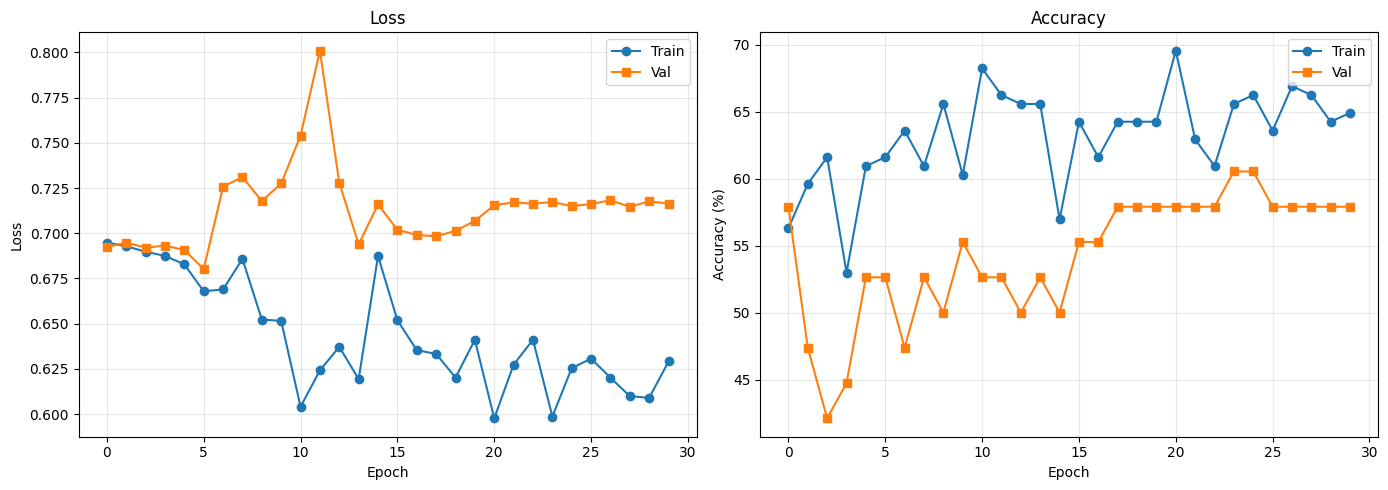

In [14]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train', marker='o')
axes[0].plot(val_losses, label='Val', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, label='Train', marker='o')
axes[1].plot(val_accs, label='Val', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300)
plt.show()

## Load Best Model

In [15]:

checkpoint = torch.load('HitNet_Best.pth')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")

Loaded best model from epoch 24


## Evaluation

In [16]:

val_loss, val_acc, final_preds, final_labels = validate(model, test_loader, criterion, device)

print(f"\nTest Accuracy: {val_acc:.2f}%")
print(f"Test Loss: {val_loss:.4f}")


Test Accuracy: 60.53%
Test Loss: 0.7173


## Classification Report

In [17]:

class_names = ['Miss', 'Land']
print("\nClassification Report:")
print(classification_report(final_labels, final_preds, target_names=class_names, digits=4))


Classification Report:
              precision    recall  f1-score   support

        Miss     0.4375    0.5385    0.4828        13
        Land     0.7273    0.6400    0.6809        25

    accuracy                         0.6053        38
   macro avg     0.5824    0.5892    0.5818        38
weighted avg     0.6281    0.6053    0.6131        38



## Confusion Matrix

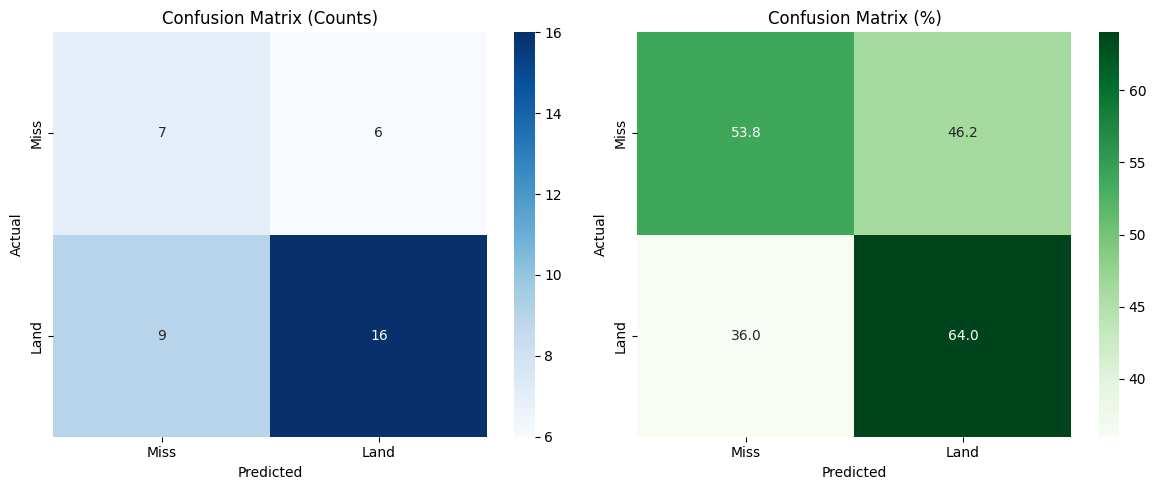

In [18]:

cm = confusion_matrix(final_labels, final_preds)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix (Counts)')

cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix (%)')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

## Per-Class Metrics

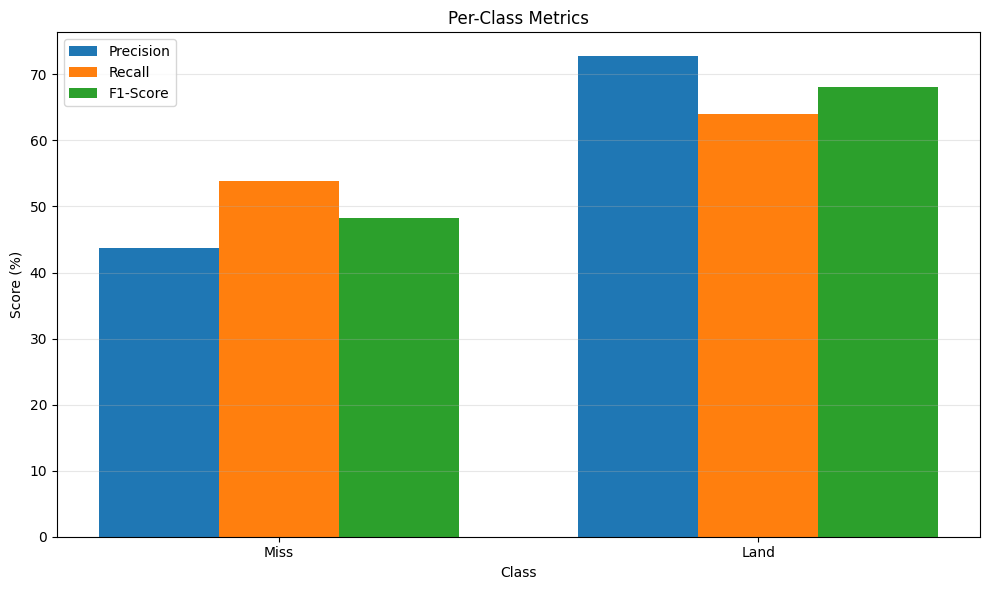

In [19]:
precision, recall, f1, support = precision_recall_fscore_support(
    final_labels, final_preds, average=None
)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(class_names))
width = 0.25

ax.bar(x - width, precision * 100, width, label='Precision')
ax.bar(x, recall * 100, width, label='Recall')
ax.bar(x + width, f1 * 100, width, label='F1-Score')

ax.set_xlabel('Class')
ax.set_ylabel('Score (%)')
ax.set_title('Per-Class Metrics')
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('metrics.png', dpi=300)
plt.show()

## Save Model

In [20]:

torch.save(model.state_dict(), 'HitNet_Final.pth')
print("Model saved: HitNet_Final.pth")

Model saved: HitNet_Final.pth
